In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_json('data/dataset.json')

train_df = df.iloc[:50].copy()

print("total data:", len(train_df))
train_df.head()

total data: 50


,summary,description,reporter_name,project_name,Assignee,Priority,Type,id
0,Issue reported: Search bar expands unexpectedl...,Details provided:\n**Problem:** The search bar...,user_079,Unidentified Roe,user_128,Normal,Bug,1
1,Detected anomaly: AI Assistant Icon Color Miss...,Observed behaviour:\nThe AI Assistant menu ite...,user_062,Unidentified Roe,user_018,Normal,Task,2
2,User noticed: Preserve table filtering after n...,"Description:\n**Problem:**\nCurrently, when a ...",user_134,Fast Buffalo,None,Normal,Bug,3
3,Issue reported: Containers crash with Failed t...,Observed behaviour:\nWhen running six containe...,user_105,Unidentified Hedgehog,user_126,Major,Bug,4
4,System shows: Inconsistent inlay hints for fun...,Summary of issue:\nThere is an inconsistency i...,user_078,Lazy Whale,user_056,Normal,Bug,5


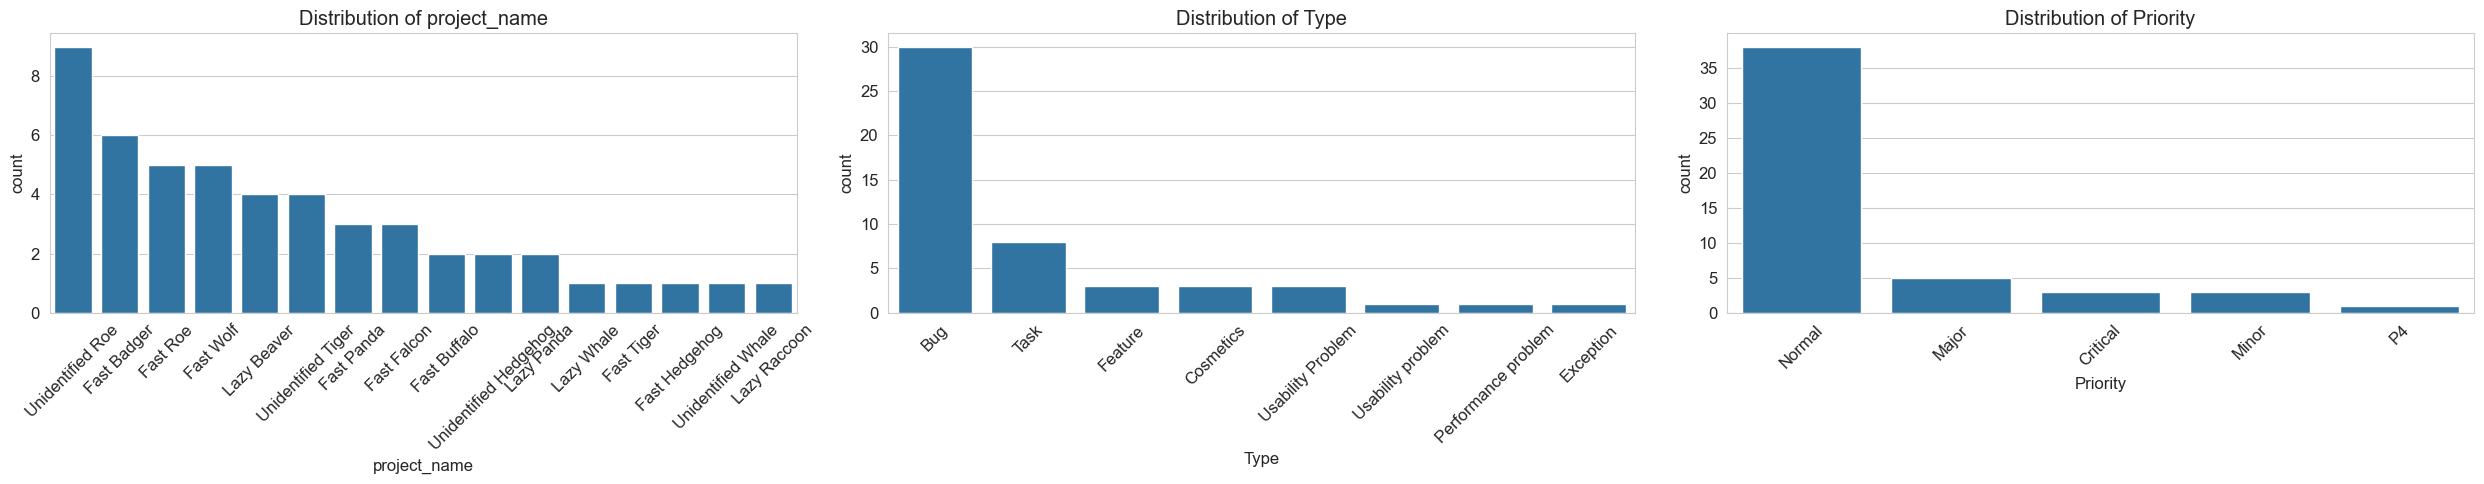

In [23]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (25, 5)
plt.rcParams['font.size'] = 12

targets = ['project_name', 'Type', 'Priority']

fig, axes = plt.subplots(1, 3)

for i, target in enumerate(targets):
    sns.countplot(x=target, data=train_df, ax=axes[i], order=train_df[target].value_counts().index)
    axes[i].set_title(f'Distribution of {target}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/target_distributions.png', bbox_inches='tight')
plt.show()

Note: The target columns are imbalanced.
- Project: Unidentified Roe and Fast Badger are the most frequent categories.
- Type: Most issues are labeled as Bug, with very few samples in other types.
- Priority: The majority of issues are Normal, far more than other priorities. 

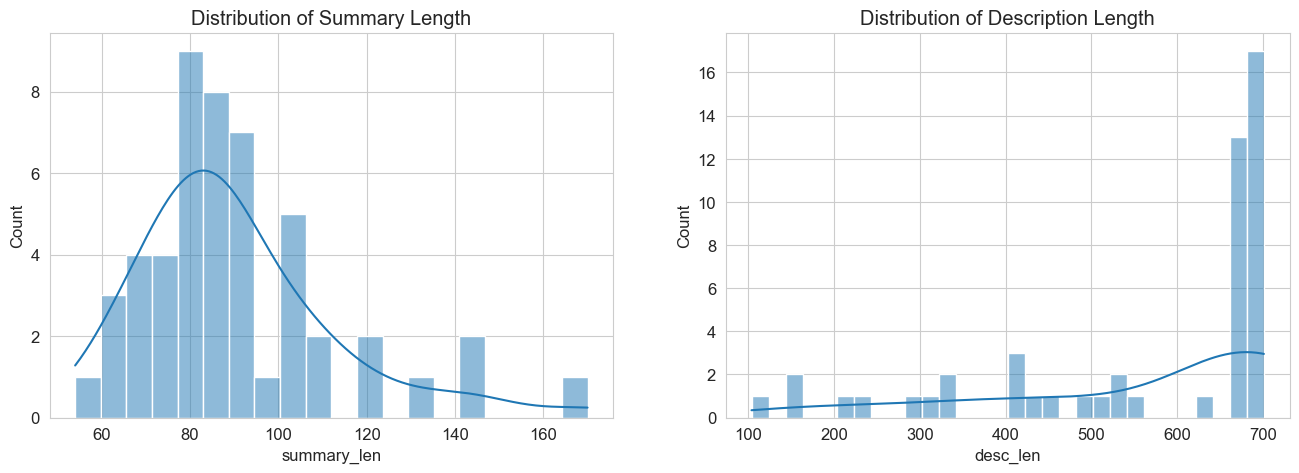

len of all:


,summary_len,desc_len
count,50.00000,50.000000
mean,90.36000,562.040000
std,22.55855,180.075377
min,54.00000,104.000000
25%,78.00000,430.750000
50%,86.50000,679.000000
75%,101.75000,692.000000
max,170.00000,701.000000


In [25]:
# cal len of summary, description
train_df['summary_len'] = train_df['summary'].str.len()
train_df['desc_len'] = train_df['description'].str.len()

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train_df['summary_len'], ax=axes[0], bins=20, kde=True)
sns.histplot(train_df['desc_len'], ax=axes[1], bins=30, kde=True)
axes[0].set_title('Distribution of Summary Length')
axes[1].set_title('Distribution of Description Length')

plt.savefig('images/text_length_distribution.png', bbox_inches='tight')
plt.show()

print("len of all:")
train_df[['summary_len', 'desc_len']].describe()

Note: Analysis of Text Length
- Summary Length: The length of the summaries follows a relatively normal distribution, with an average length of about 90 characters. Most summaries are between 78 and 102 characters long.
- Description Length: The description lengths are heavily skewed towards longer texts. The majority of descriptions are clustered at the high end, between 650 and 700 characters, with a median length of 679 characters.

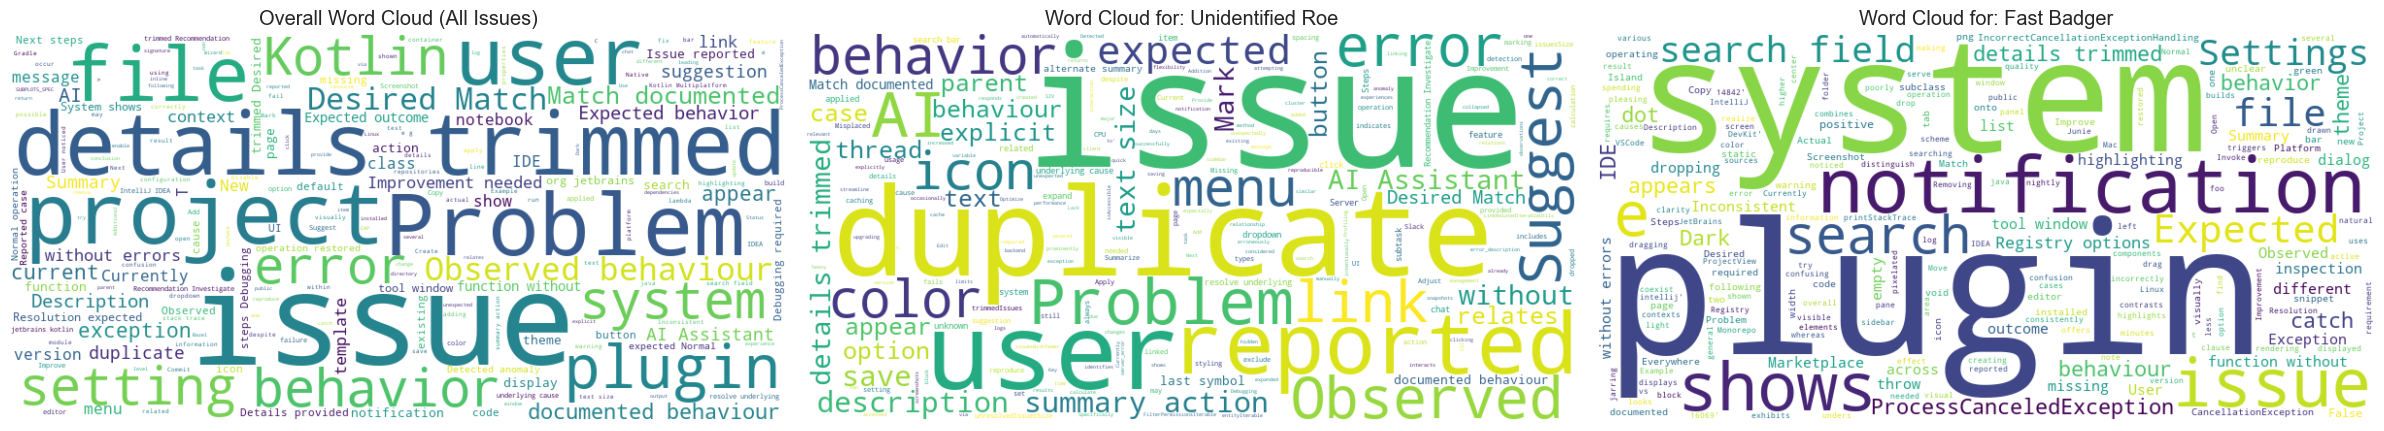

In [28]:
from wordcloud import WordCloud

if 'text' not in train_df.columns:
    train_df['text'] = train_df['summary'] + ' ' + train_df['description']

all_text = ' '.join(train_df['text'])

# Select Top 2
top_projects = train_df['project_name'].value_counts().index[:2]
project_1_text = ' '.join(train_df[train_df['project_name'] == top_projects[0]]['text'])
project_2_text = ' '.join(train_df[train_df['project_name'] == top_projects[1]]['text'])


fig, axes = plt.subplots(1, 3, figsize=(24, 8))

wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(all_text)
axes[0].imshow(wordcloud_all, interpolation='bilinear')
axes[0].set_title('Overall Word Cloud (All Issues)')
axes[0].axis('off')

wordcloud_p1 = WordCloud(width=800, height=400, background_color='white').generate(project_1_text)
axes[1].imshow(wordcloud_p1, interpolation='bilinear')
axes[1].set_title(f'Word Cloud for: {top_projects[0]}')
axes[1].axis('off')

wordcloud_p2 = WordCloud(width=800, height=400, background_color='white').generate(project_2_text)
axes[2].imshow(wordcloud_p2, interpolation='bilinear')
axes[2].set_title(f'Word Cloud for: {top_projects[1]}')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('images/wordcloud_comparison.png', bbox_inches='tight')
plt.show()

Note: each project has a distinct set of common keywords, which will be very helpful for classification.
- Fast Badger: The keywords here are frequently related to system functionality, with prominent words like notification, plugin, settings, and search.
- Unidentified Roe: This project's keywords seem to focus more on user-reported visual or behavioral issues, with common terms such as duplicate, observed, color, icon, and AI.